In [871]:
import numpy as np
import torch

In [872]:
import torchvision.models
model1 = torchvision.models.squeezenet1_0(
    weights=torchvision.models.SqueezeNet1_0_Weights.DEFAULT)
model2 = torchvision.models.resnet18(pretrained=True)

/home.nfs/hornirom/lab2/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home.nfs/hornirom/lab2/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Preprocessing images

In [873]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2

batch_size = 16

train_dataset = ImageFolder(root='./PACS_cartoon/train',
                            transform=v2.Compose([
    v2.Resize(227),
    v2.AutoAugment(torchvision.transforms.
                   autoaugment.AutoAugmentPolicy.IMAGENET,
                   torchvision.transforms.
                   InterpolationMode.BILINEAR),
    v2.ToTensor()
]))

test_dataset = ImageFolder(root='./PACS_cartoon/test',
                           transform=v2.Compose([
    v2.Resize(227),
    v2.ToTensor()
]))

print(len(train_dataset), len(test_dataset))


2108 236


/home.nfs/hornirom/lab2/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [874]:
trn_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True)

tst_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=True)

# Training the base model

## For the base model I used my own CNN
Its architecture looks like

conv[3x3] - max pool - conv[3x3] - max pool - conv[3x3] - max pool - flattening - fully-connected - dropout 33% - fully-connected

ReLU was used as an activation function

In [875]:
import importlib
import lab
importlib.reload(lab)
from lab import *

base_model = BaseModel()

In [876]:
learning_rate = 0.001
epochs = 50

In [877]:
patience = 5

final_accs = []
final_losses = []

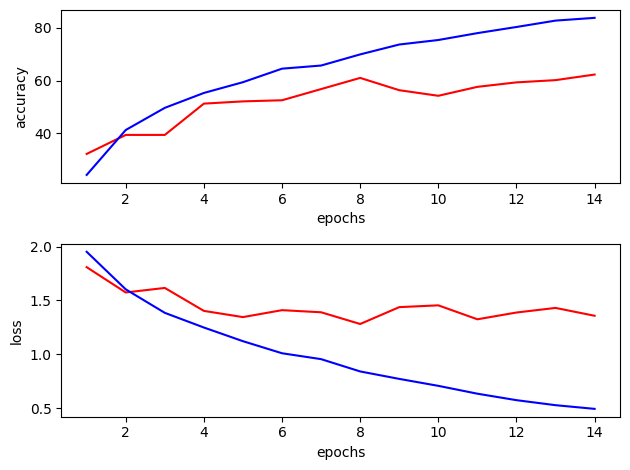

In [878]:
device = torch.device("cpu")
base_model = base_model.to(device)
optimizer = torch.optim.Adam(base_model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

final_loss, final_acc = train_test_model(base_model, trn_loader,
                                         tst_loader, optimizer, scheduler,
                                         device, epochs, batch_size,
                                         'base_model', patience)

final_accs.append(final_acc)
final_losses.append(final_loss);

### blue for training, red for validation

In [879]:
print(f'Final accuracy: {final_acc * 100.:.3f}%. '
      f'Final loss: {final_loss:.3f}.')

Final accuracy: 61.017%. Final loss: 1.281.


# A. Training ResNet18 with linear probing

In [880]:
learning_rate = 3e-4

In [881]:
model2.fc = nn.Linear(in_features=model2.fc.in_features, out_features=7)

for param in model2.parameters():
    param.requires_grad = False
for param in model2.fc.parameters():
    param.requires_grad = True
model = model2.to(device)

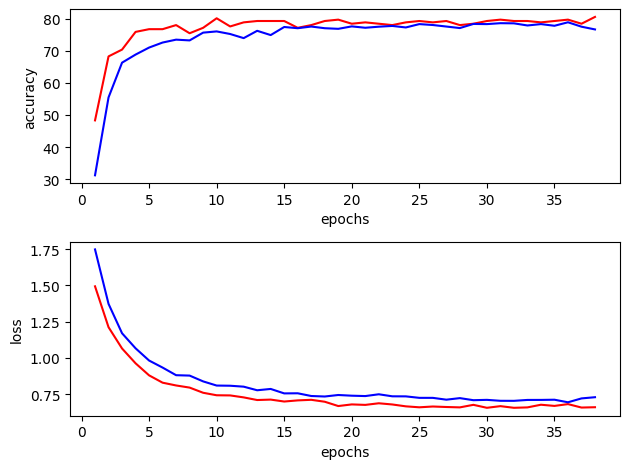

In [882]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

final_loss, final_acc = train_test_model(
    model, trn_loader, tst_loader, optimizer, scheduler, device,
    epochs, batch_size, 'resnet18_linear_probing', patience)

final_accs.append(final_acc)
final_losses.append(final_loss);

### blue for training, red for validation

In [883]:
print(f'Final accuracy: {final_acc * 100.:.3f}%. '
      f'Final loss: {final_loss:.3f}.')

Final accuracy: 79.237%. Final loss: 0.656.


# B. Training ResNet18 with bias tuning

In [884]:
learning_rate = 3e-4

In [885]:
model2.fc = nn.Linear(in_features=model2.fc.in_features, out_features=7)

for param in model2.parameters():
    param.requires_grad = False
for param in model2.fc.parameters():
    param.requires_grad = True
biases = []
fc = []
for name, param in model2.named_parameters():
    if name.startswith("fc") and not name.endswith("bias"):
       fc.append(param)
    if name.endswith('bias'):
        biases.append(param)
        param.requires_grad = True
model = model2.to(device)

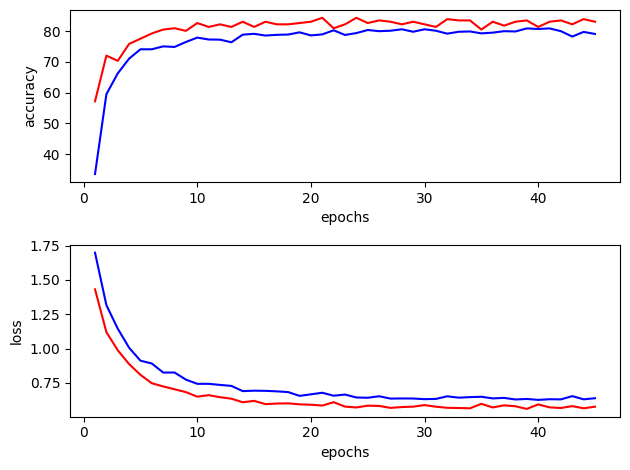

In [886]:
optimizer = torch.optim.AdamW([
    {"params": fc, "lr": learning_rate},
    {"params": biases, "lr": learning_rate / 10},
])
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

final_loss, final_acc = train_test_model(
    model, trn_loader, tst_loader, optimizer, scheduler, device,
    epochs, batch_size, 'resnet18_bias_tuning', patience)

final_accs.append(final_acc)
final_losses.append(final_loss);

### blue for training, red for validation

In [887]:
print(f'Final accuracy: {final_acc * 100.:.3f}%. '
      f'Final loss: {final_loss:.3f}.')

Final accuracy: 83.475%. Final loss: 0.560.


# C. Tuning last N layers of ResNet18

## 1) Tuning 1 last layer

In [888]:
learning_rate = 3e-4

In [889]:
model2.fc = nn.Linear(in_features=model2.fc.in_features, out_features=7)

for param in model2.parameters():
    param.requires_grad = False
for param in model2.fc.parameters():
    param.requires_grad = True
for name, param in model2.named_parameters():
    if name.startswith('layer4'):
        param.requires_grad = True
fc = []
layer4 = []
for name, param in model2.named_parameters():
    if name.startswith("fc"):
        fc.append(param)
    if name.startswith('layer4'):
        layer4.append(param)
model = model2.to(device)

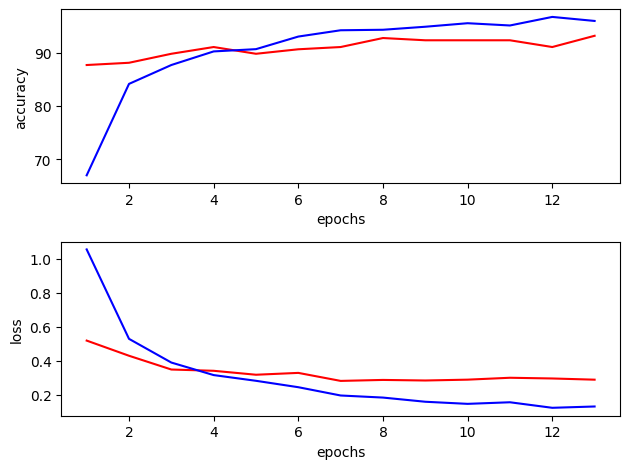

In [890]:
optimizer = torch.optim.AdamW([
    {"params": fc, "lr": learning_rate},
    {"params": layer4, "lr": learning_rate / 10},
])
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

final_loss, final_acc = train_test_model(
    model, trn_loader, tst_loader, optimizer, scheduler, device, epochs,
    batch_size, 'resnet18_tuning_1_last_layer', patience)

final_accs.append(final_acc)
final_losses.append(final_loss);

### blue for training, red for validation

In [891]:
print(f'Final accuracy: {final_acc * 100.:.3f}%. '
      f'Final loss: {final_loss:.3f}.')

Final accuracy: 91.102%. Final loss: 0.281.


## 2) Tuning 2 last layers

In [892]:
model2.fc = nn.Linear(in_features=model2.fc.in_features, out_features=7)

for param in model2.parameters():
    param.requires_grad = False
for param in model2.fc.parameters():
    param.requires_grad = True
for name, param in model2.named_parameters():
    if name.startswith('layer4') or name.startswith('layer3'):
        param.requires_grad = True
fc = []
layer4 = []
layer3 = []
for name, param in model2.named_parameters():
    if name.startswith("fc"):
        fc.append(param)
    if name.startswith('layer4'):
        layer4.append(param)
    if name.startswith('layer3'):
        layer3.append(param)
model = model2.to(device)

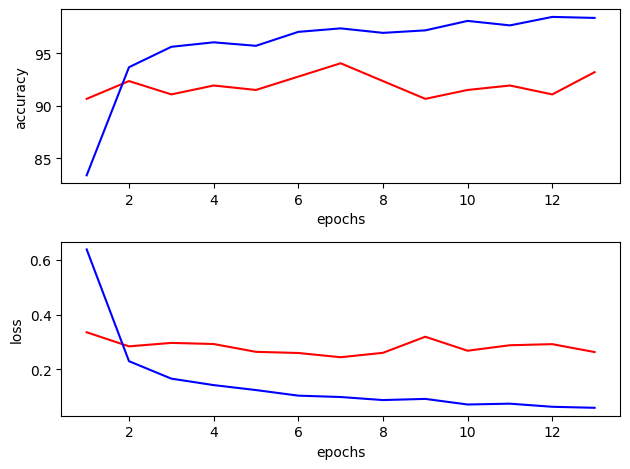

In [893]:
optimizer = torch.optim.AdamW([
    {"params": fc, "lr": learning_rate},
    {"params": layer4, "lr": learning_rate / 10},
    {"params": layer3, "lr": learning_rate / 100},
])
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

final_loss, final_acc = train_test_model(
    model, trn_loader, tst_loader, optimizer, scheduler, device, epochs,
    batch_size, 'resnet18_tuning_2_last_layers', patience)

final_accs.append(final_acc)
final_losses.append(final_loss);

### blue for training, red for validation

In [894]:
print(f'Final accuracy: {final_acc * 100.:.3f}%. '
      f'Final loss: {final_loss:.3f}.')

Final accuracy: 94.068%. Final loss: 0.244.


## 3) Tuning 3 last layers

In [895]:
model2.fc = nn.Linear(in_features=model2.fc.in_features, out_features=7)

for param in model2.parameters():
    param.requires_grad = True
for name, param in model2.named_parameters():
    if name.startswith('layer1'):
        param.requires_grad = False
fc = []
layer4 = []
layer3 = []
layer2 = []
for name, param in model2.named_parameters():
    if name.startswith("fc"):
        fc.append(param)
    if name.startswith('layer4'):
        layer4.append(param)
    if name.startswith('layer3'):
        layer3.append(param)
    if name.startswith('layer2'):
        layer2.append(param)
model = model2.to(device)

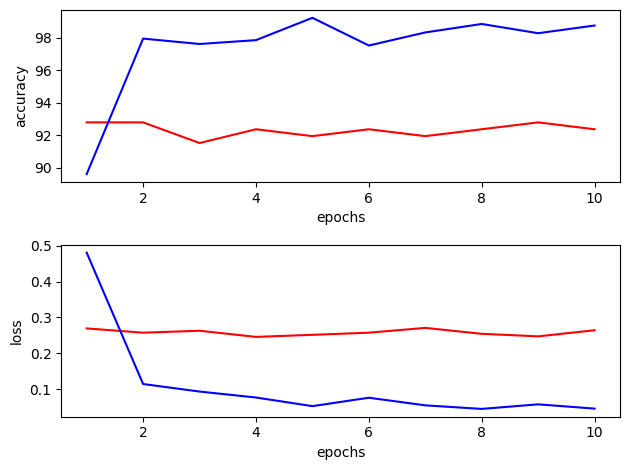

In [896]:
optimizer = torch.optim.AdamW([
    {"params": fc, "lr": learning_rate},
    {"params": layer4, "lr": learning_rate / 10},
    {"params": layer3, "lr": learning_rate / 100},
    {"params": layer2, "lr": 1e-6},
])
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

final_loss, final_acc = train_test_model(
    model, trn_loader, tst_loader, optimizer, scheduler, device, epochs,
    batch_size, 'resnet18_tuning_3_last_layers', patience)

final_accs.append(final_acc)
final_losses.append(final_loss);

### blue for training, red for validation

In [897]:
print(f'Final accuracy: {final_acc * 100.:.3f}%. '
      f'Final loss: {final_loss:.3f}.')

Final accuracy: 92.373%. Final loss: 0.246.


## 4) Tuning all the layers

In [898]:
model2.fc = nn.Linear(in_features=model2.fc.in_features, out_features=7)

for param in model2.parameters():
    param.requires_grad = True

fc = []
layer4 = []
layer3 = []
layer12 = []
for name, param in model2.named_parameters():
    if name.startswith("fc"):
        fc.append(param)
    if name.startswith('layer4'):
        layer4.append(param)
    if name.startswith('layer3'):
        layer3.append(param)
    if name.startswith('layer2') or name.startswith('layer1'):
        layer12.append(param)
model = model2.to(device)

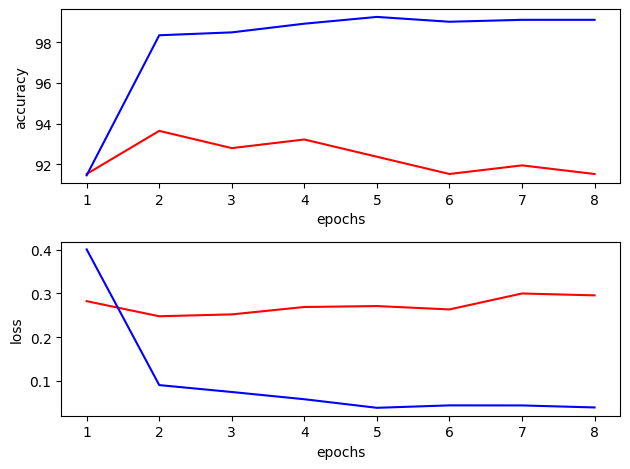

In [899]:
optimizer = torch.optim.AdamW([
    {"params": fc, "lr": learning_rate},
    {"params": layer4, "lr": learning_rate / 10},
    {"params": layer3, "lr": learning_rate / 100},
    {"params": layer12, "lr": 1e-6},
])
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

final_loss, final_acc = train_test_model(
    model, trn_loader, tst_loader, optimizer, scheduler, device, epochs,
    batch_size, 'resnet18_tuning_all_the_layers', patience)

final_accs.append(final_acc)
final_losses.append(final_loss);

### blue for training, red for validation

In [900]:
print(f'Final accuracy: {final_acc * 100.:.3f}%. '
      f'Final loss: {final_loss:.3f}.')

Final accuracy: 93.644%. Final loss: 0.248.


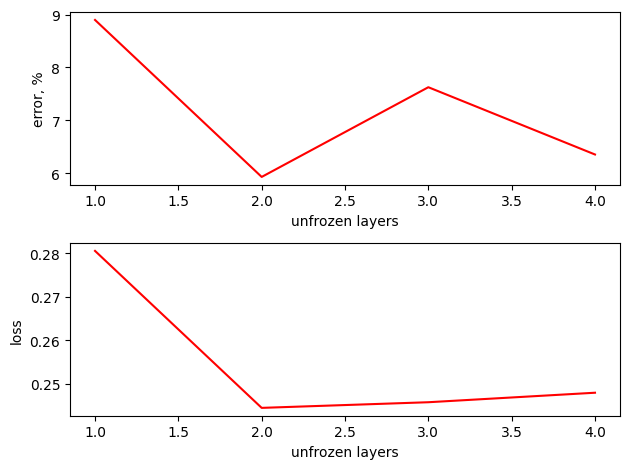

In [967]:
fig, axs = plt.subplots(2, 1)

last_accs = final_accs[-4:]

axs[0].plot(np.arange(1, 5),
            (np.ones((len(last_accs),)) - last_accs) * 100.,
            'r', label='test error')
axs[0].set_xlabel('unfrozen layers')
axs[0].set_ylabel('error, %')

axs[1].plot(np.arange(1, 5), final_losses[-4:], 'r', label='test loss')
axs[1].set_xlabel('unfrozen layers')
axs[1].set_ylabel('loss')

plt.tight_layout()
plt.show()

fig.savefig("unfrozen_layers.png", dpi=300)

# Visualization of Layer Activations

In [941]:
from PIL import Image
from torchvision import transforms

img = Image.open("./PACS_cartoon/test/person/pic_427.jpg")

transform = transforms.Compose([
    transforms.Resize(227),
    transforms.ToTensor()
])

image = transform(img)
input_tensor = image.unsqueeze(0)

In [960]:
import random

models = [
    'base_model',
    'resnet18_linear_probing',
    'resnet18_bias_tuning',
    'resnet18_tuning_1_last_layer',
    'resnet18_tuning_2_last_layers',
    'resnet18_tuning_3_last_layers',
    'resnet18_tuning_all_the_layers'
]

random_model = random.choice(models)
best_model = models[np.argmax(final_accs)]
print('Random model: ' + random_model + '. Best model: ' + best_model)

rmodel = model2 if random_model.startswith('resnet18') else BaseModel()
bmodel = model2.to(device)
rmodel.load_state_dict(torch.load(random_model + '.pt'))
bmodel.load_state_dict(torch.load(best_model + '.pt'));

Random model: resnet18_tuning_1_last_layer. Best model: resnet18_tuning_2_last_layers


## Random Model

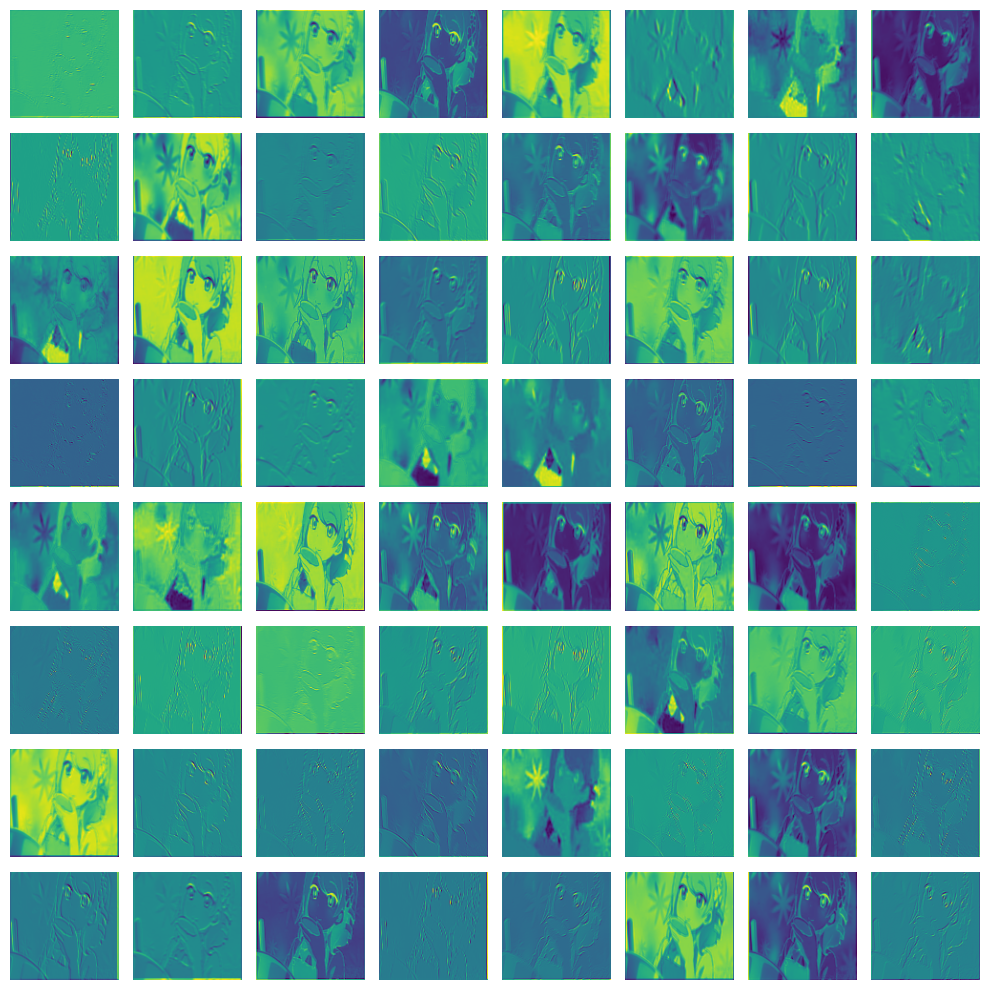

In [965]:
rmodel.eval()
input_image = image.unsqueeze(0)

first_conv = None
for layer in rmodel.modules():
    if isinstance(layer, torch.nn.Conv2d):
        first_conv = layer
        break

activation = {}

def hook_fn(module, input, output):
    activation['conv1'] = output.detach()

hook = first_conv.register_forward_hook(hook_fn)

_ = rmodel(input_image)

hook.remove()

feature_maps = activation['conv1']

feature_maps = feature_maps.squeeze(0)
num_channels = feature_maps.shape[0]

fig, axes = plt.subplots(8, 8, figsize=(10,10))
axes = axes.flatten()

for i in range(num_channels):
    axes[i].imshow(feature_maps[i].cpu(), cmap="viridis")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

fig.savefig("random_model_map.png", dpi=300)

## Best Model

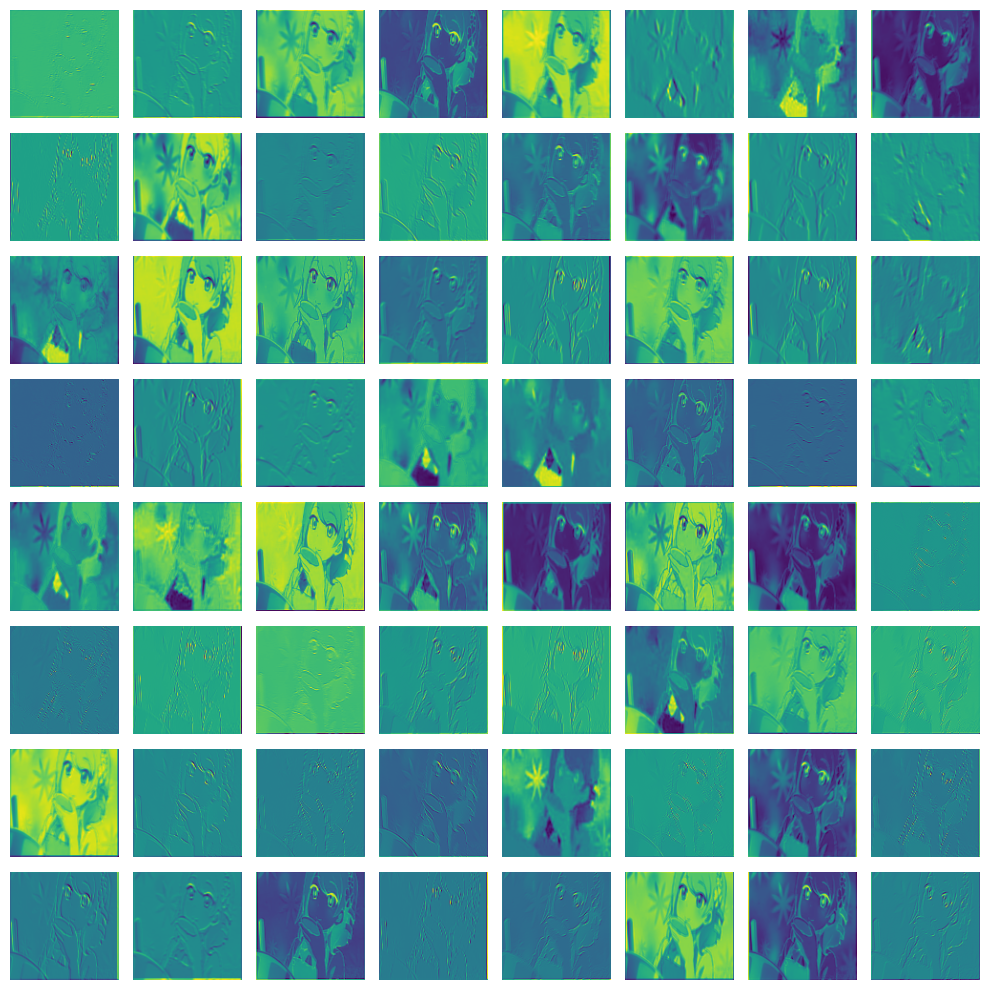

In [962]:
bmodel.eval()

input_image = image.unsqueeze(0)

first_conv = None
for layer in bmodel.modules():
    if isinstance(layer, torch.nn.Conv2d):
        first_conv = layer
        break

activation = {}

def hook_fn(module, input, output):
    activation['conv1'] = output.detach()

hook = first_conv.register_forward_hook(hook_fn)

_ = bmodel(input_image)

hook.remove()

feature_maps = activation['conv1']

feature_maps = feature_maps.squeeze(0)
num_channels = feature_maps.shape[0]

fig, axes = plt.subplots(8, 8, figsize=(10,10))
axes = axes.flatten()

for i in range(num_channels):
    axes[i].imshow(feature_maps[i].cpu(), cmap="viridis")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

fig.savefig("best_model_map.png", dpi=300)